## K-means in Scikit-Learn

Suppose I have this data:

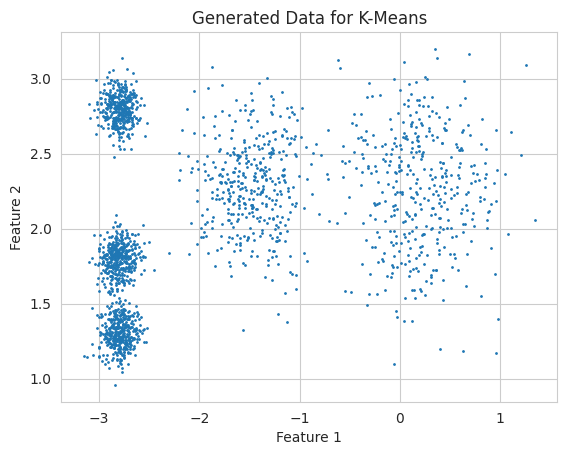

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
sns.set_style('whitegrid')

blob_centers = np.array([[0.2, 2.3], [-1.5, 2.3], [-2.8, 1.8], [-2.8, 2.8], [-2.8, 1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=7)

plt.scatter(X[:,0], X[:,1], s=1)
plt.title("Generated Data for K-Means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Using K-means:

In [2]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=43, n_init='auto') # Added n_init='auto' for modern sklearn
y_pred = kmeans.fit_predict(X)

# or just kmeans.fit(X)
print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[-2.80389616  1.80117999]
 [ 0.20876306  2.25551336]
 [-2.79290307  2.79641063]
 [-1.46679593  2.28585348]
 [-2.80037642  1.30082566]]


Predicting with K-means:

In [3]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
print("Predictions for new data points:")
print(kmeans.predict(X_new))

Predictions for new data points:
[1 1 2 2]


Let's visualize the clusters and the new predictions.

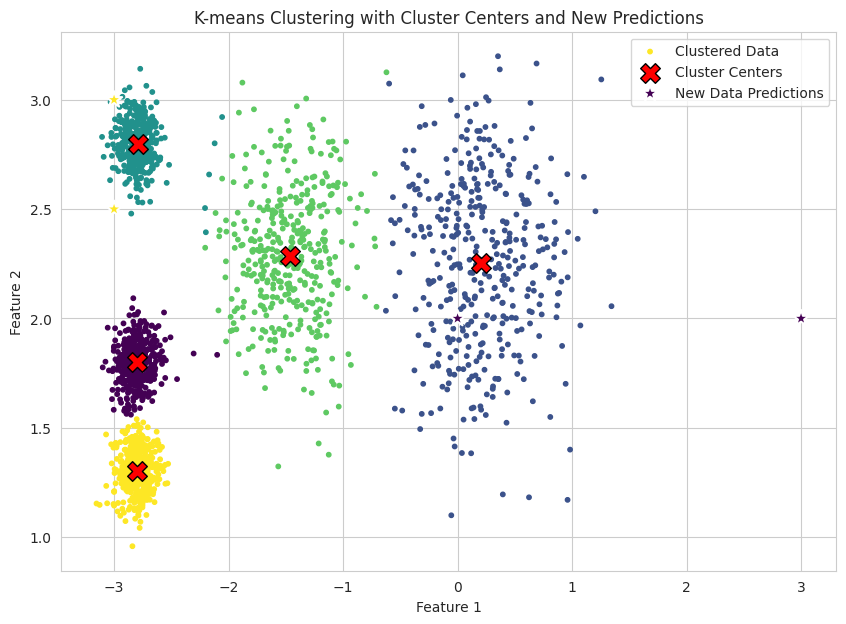

In [6]:
plt.figure(figsize=(10, 7))
plt.scatter(X[:,0], X[:,1], c=y_pred, s=10, cmap='viridis', label='Clustered Data')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, marker='X', c='red', edgecolor='black', label='Cluster Centers')

# Plot new data points and their predicted clusters
new_predictions = kmeans.predict(X_new)
plt.scatter(X_new[:, 0], X_new[:, 1], s=150, marker='*', c=new_predictions, cmap='viridis', edgecolor='white', linewidth=1.5, label='New Data Predictions')

plt.title('K-means Clustering with Cluster Centers and New Predictions')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## Exploring K-means with Different Random Seeds and Inertia

K-means is sensitive to the initial placement of centroids, which is often determined by a random seed. We will now run the algorithm with a few different random states and observe the resulting inertia. Inertia is a measure of how internally coherent clusters are, with lower values generally indicating better clustering.

In [7]:
inertias = []
random_states = [0, 42, 123, 789, 999]

print("Running K-means with different random seeds and collecting inertia:")
for rs in random_states:
    kmeans_rs = KMeans(n_clusters=k, random_state=rs, n_init='auto')
    kmeans_rs.fit(X)
    inertias.append((rs, kmeans_rs.inertia_))
    print(f"  Random State: {rs}, Inertia: {kmeans_rs.inertia_:.2f}")

print("\nAll Inertias:")
for rs, inertia_val in inertias:
    print(f"  Random State: {rs}: {inertia_val:.2f}")

Running K-means with different random seeds and collecting inertia:
  Random State: 0, Inertia: 211.60
  Random State: 42, Inertia: 224.07
  Random State: 123, Inertia: 236.97
  Random State: 789, Inertia: 211.60
  Random State: 999, Inertia: 236.97

All Inertias:
  Random State: 0: 211.60
  Random State: 42: 224.07
  Random State: 123: 236.97
  Random State: 789: 211.60
  Random State: 999: 236.97


### Dashboard: Visualizing Clusters and Inertia for Selected Seeds

Below, we'll visualize the clustering results for a few distinct random seeds to compare the resulting point distributions and their respective inertia scores.

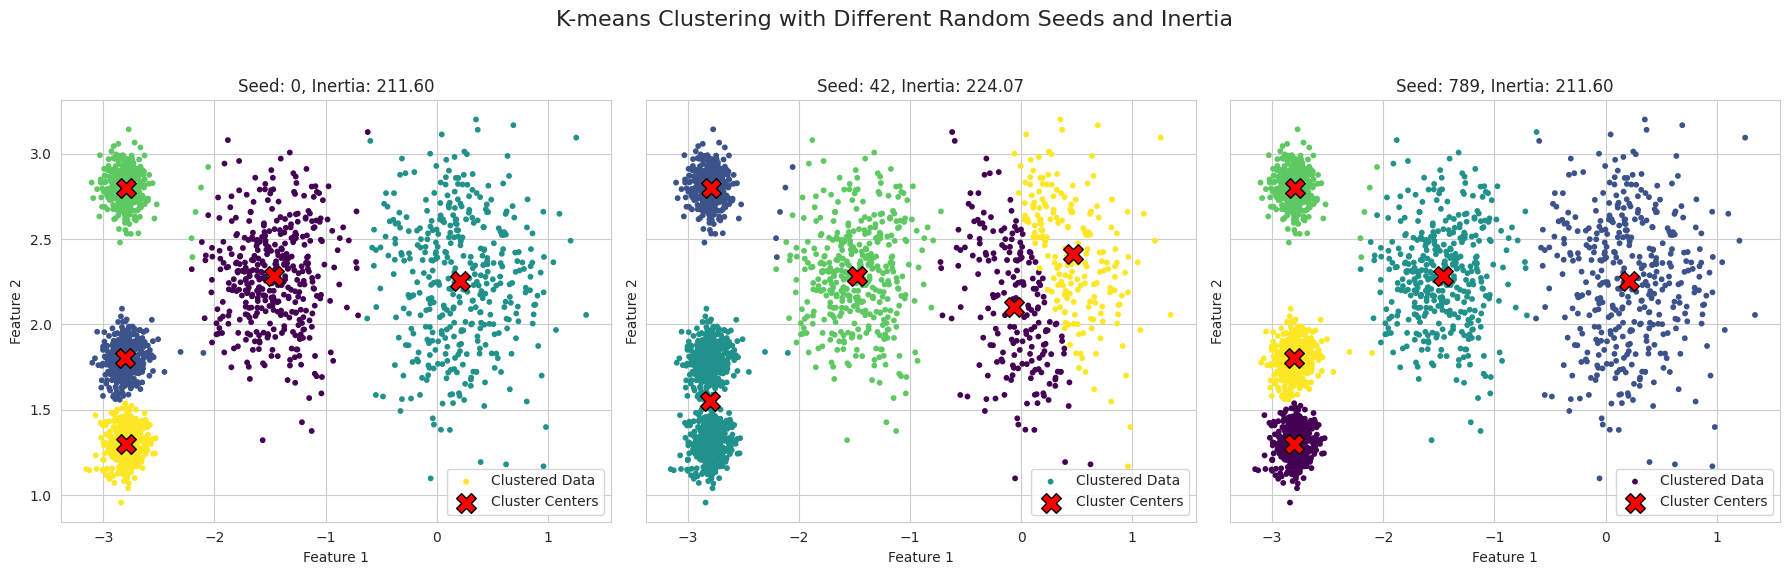

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
axes = axes.flatten()

selected_seeds = [0, 42, 789] # Choose a few seeds to visualize

for i, rs in enumerate(selected_seeds):
    kmeans_rs = KMeans(n_clusters=k, random_state=rs, n_init='auto')
    y_pred_rs = kmeans_rs.fit_predict(X)
    inertia_rs = kmeans_rs.inertia_

    ax = axes[i]
    ax.scatter(X[:, 0], X[:, 1], c=y_pred_rs, s=10, cmap='viridis', label='Clustered Data')
    ax.scatter(kmeans_rs.cluster_centers_[:, 0], kmeans_rs.cluster_centers_[:, 1], s=200, marker='X', c='red', edgecolor='black', label='Cluster Centers')
    ax.set_title(f'Seed: {rs}, Inertia: {inertia_rs:.2f}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    ax.grid(True)

plt.suptitle('K-means Clustering with Different Random Seeds and Inertia', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()